In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\AiK\Machine Learning Projects\CCTV Maintanence\cctv_maintenance_dataset.csv")
df.head()

,camera_id,age_days,daily_usage_hours,avg_temperature_c,avg_humidity_percent,vibration_level,signal_strength_dbm,avg_power_consumption_w,firmware_version,camera_type,location_type,manufacturer,weather_exposure,needs_maintenance
0,CAM_033553,119,990,33.2,68.8,0.39,-55.3,12.0,7,PTZ,Outdoor_Commercial,Axis,Medium,0
1,CAM_009427,678,1025,16.9,73.6,0.55,-57.8,14.0,8,Bullet,Warehouse,Axis,Medium,0
2,CAM_000199,552,1056,22.6,72.2,0.05,-52.0,13.6,3,Thermal,Indoor,Bosch,High,0
3,CAM_012447,2329,1033,25.9,77.5,0.45,-52.8,16.7,10,Bullet,Indoor,Axis,Medium,0
4,CAM_039489,339,1041,23.8,92.2,0.29,-52.8,14.9,7,Bullet,Indoor,Dahua,High,0


In [4]:
df.shape

(50000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   camera_id                50000 non-null  object 
 1   age_days                 50000 non-null  int64  
 2   daily_usage_hours        50000 non-null  int64  
 3   avg_temperature_c        50000 non-null  float64
 4   avg_humidity_percent     50000 non-null  float64
 5   vibration_level          50000 non-null  float64
 6   signal_strength_dbm      50000 non-null  float64
 7   avg_power_consumption_w  50000 non-null  float64
 8   firmware_version         50000 non-null  int64  
 9   camera_type              50000 non-null  object 
 10  location_type            50000 non-null  object 
 11  manufacturer             50000 non-null  object 
 12  weather_exposure         50000 non-null  object 
 13  needs_maintenance        50000 non-null  int64  
dtypes: float64(5), int64(4

In [6]:
df["needs_maintenance"].value_counts()

0    44707
1     5293
Name: needs_maintenance, dtype: int64

In [7]:
df.describe()

,age_days,daily_usage_hours,avg_temperature_c,avg_humidity_percent,vibration_level,signal_strength_dbm,avg_power_consumption_w,firmware_version,needs_maintenance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,363.083240,999.674760,22.027900,62.469462,0.501514,-55.035312,14.979418,5.508520,0.105860
std,363.797003,44.631382,7.983757,16.211799,0.499738,8.021901,2.994112,2.869546,0.307661
min,0.000000,812.000000,-10.000000,5.700000,0.000000,-80.000000,5.000000,1.000000,0.000000
25%,104.000000,969.000000,16.600000,51.300000,0.140000,-60.500000,13.000000,3.000000,0.000000
50%,252.000000,999.000000,22.000000,63.600000,0.350000,-55.100000,15.000000,5.000000,0.000000
75%,503.000000,1029.000000,27.400000,74.600000,0.700000,-49.600000,17.000000,8.000000,0.000000
max,3828.000000,1199.000000,45.000000,99.400000,5.000000,-30.000000,27.100000,10.000000,1.000000


In [8]:
df.duplicated().sum()

0

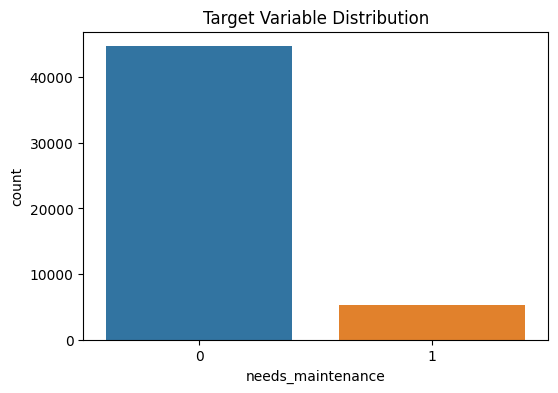

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='needs_maintenance')
plt.title("Target Variable Distribution")
plt.show()

In [10]:
numcols = df.select_dtypes(include='number').columns
catcols = df.select_dtypes(include='object').columns
print(numcols, catcols)

Index(['age_days', 'daily_usage_hours', 'avg_temperature_c',
       'avg_humidity_percent', 'vibration_level', 'signal_strength_dbm',
       'avg_power_consumption_w', 'firmware_version', 'needs_maintenance'],
      dtype='object') Index(['camera_id', 'camera_type', 'location_type', 'manufacturer',
       'weather_exposure'],
      dtype='object')


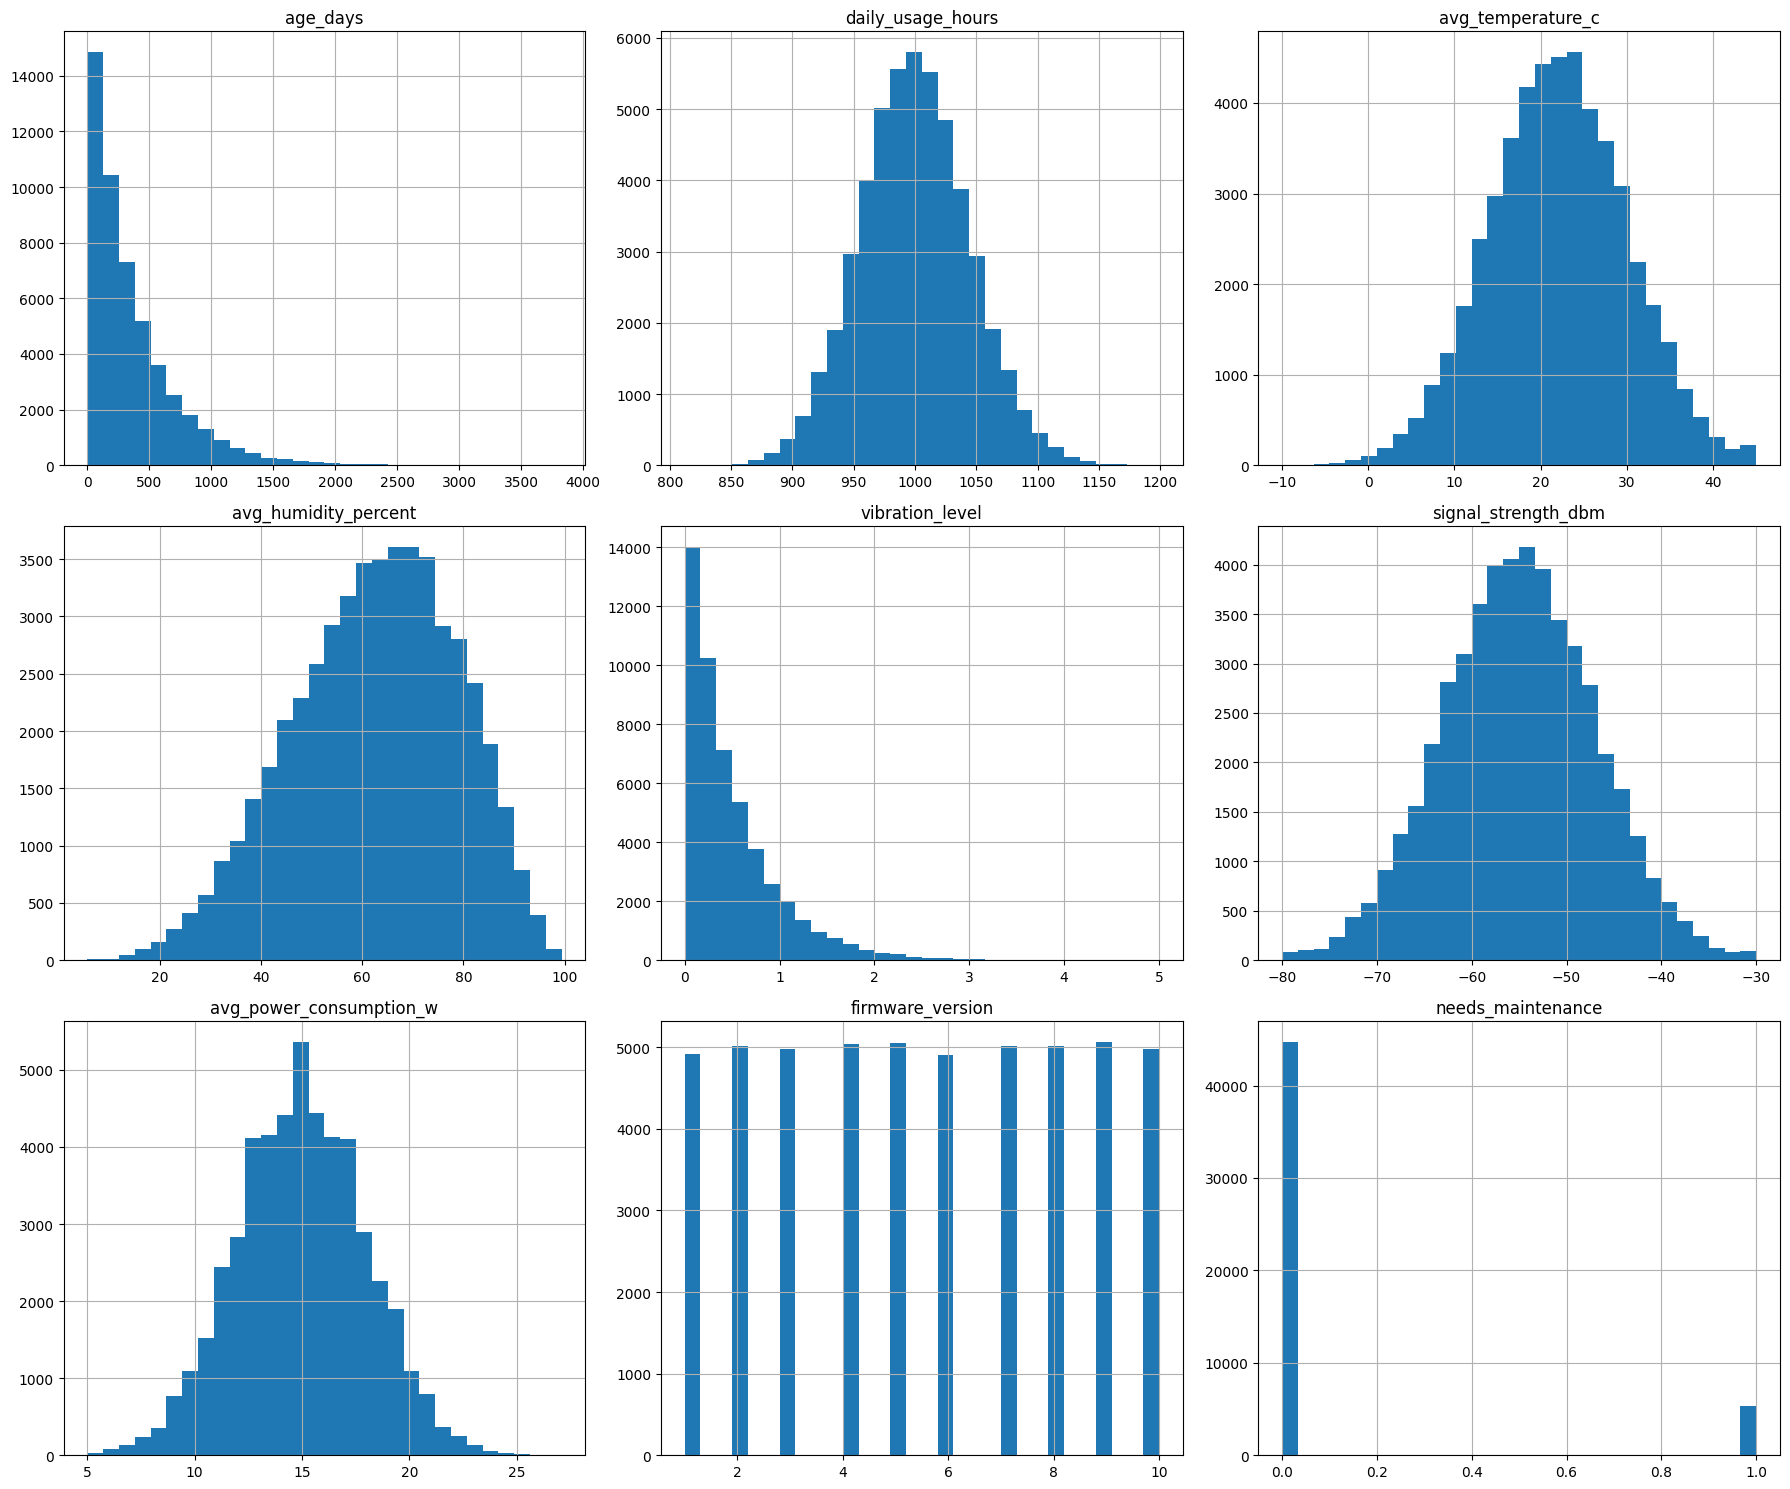

In [13]:
df[numcols].hist(figsize=(18,15), bins=30)
plt.tight_layout()
plt.show()

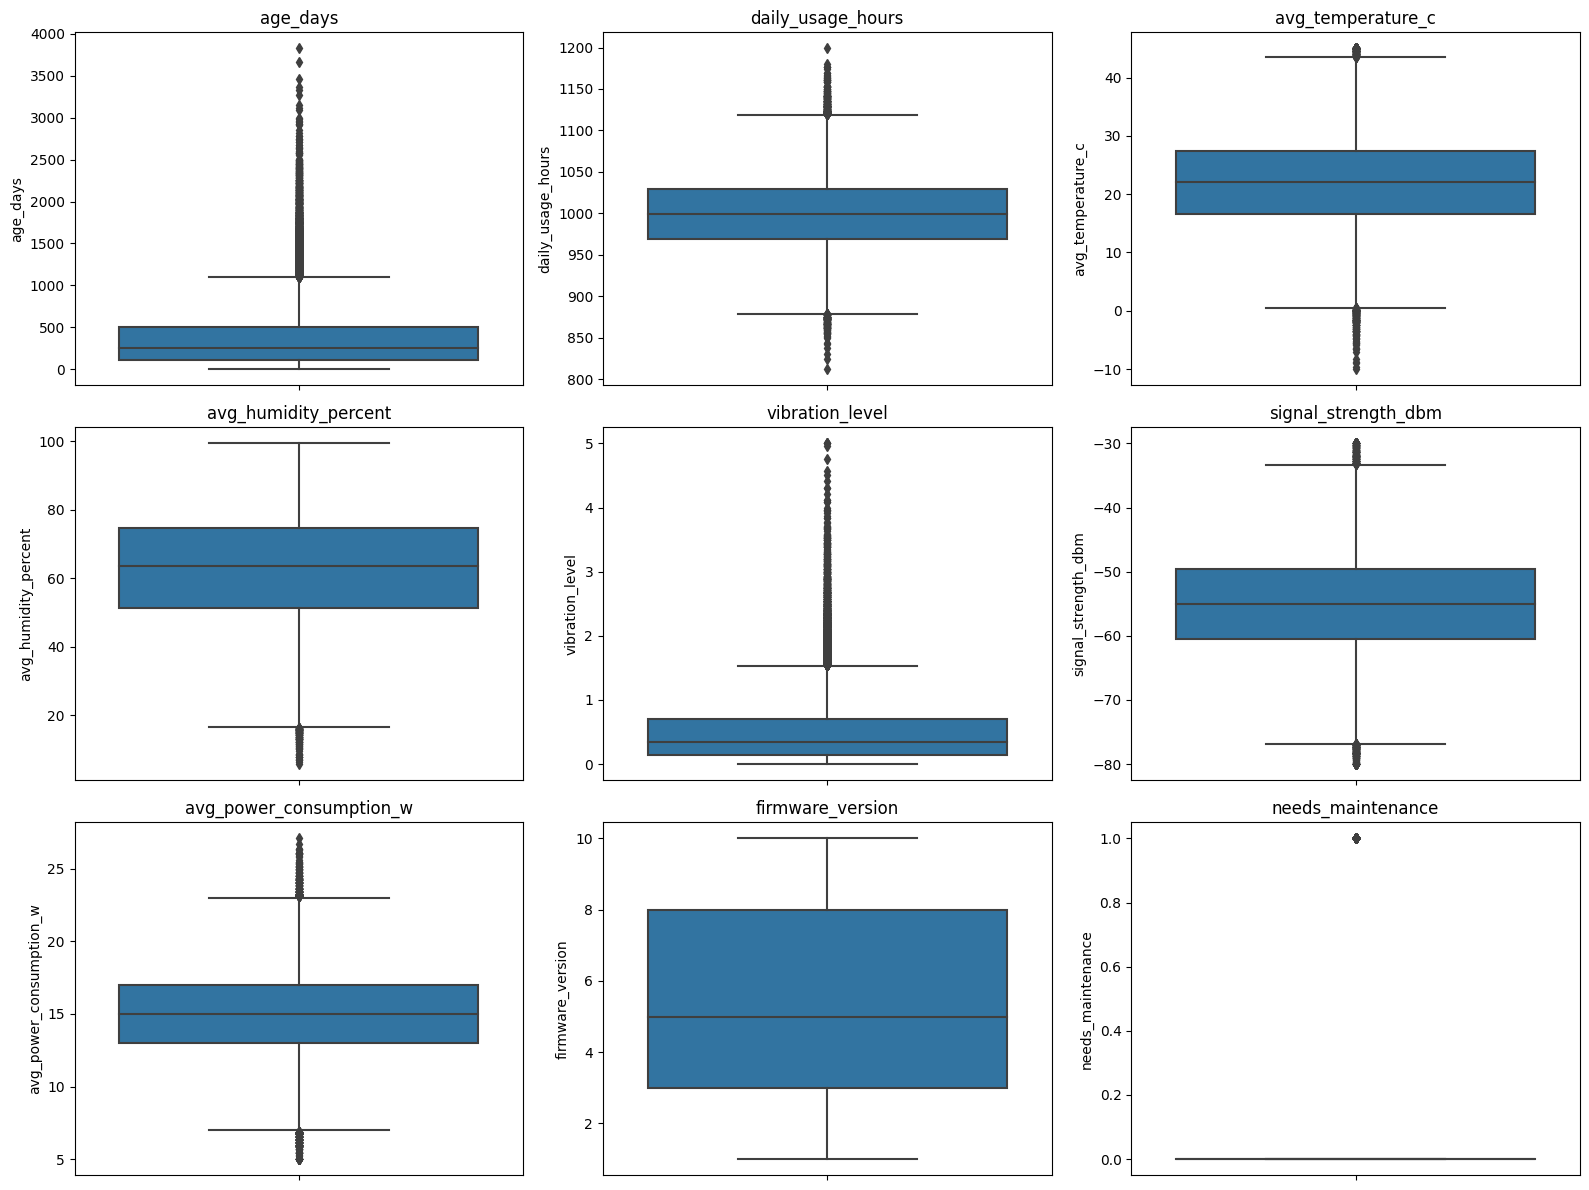

In [16]:
plt.figure(figsize=(16,12))

for i,col in enumerate(numcols):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
def outhand(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    low = Q1 - 1.5*IQR
    upp = Q3 + 1.5*IQR
    
    df[column] = df[column].clip(lower=low, upper=upp)
    return df

In [18]:
for col in numcols:
    if col != 'needs_maintenance':
        df = outhand(df, col)

In [19]:
print(df.describe())

           age_days  daily_usage_hours  avg_temperature_c  \
count  50000.000000       50000.000000       50000.000000   
mean     345.432890         999.629620          22.032016   
std      305.462267          44.329564           7.948048   
min        0.000000         879.000000           0.400000   
25%      104.000000         969.000000          16.600000   
50%      252.000000         999.000000          22.000000   
75%      503.000000        1029.000000          27.400000   
max     1101.500000        1119.000000          43.600000   

       avg_humidity_percent  vibration_level  signal_strength_dbm  \
count          50000.000000     50000.000000         50000.000000   
mean              62.475897         0.478687           -55.036058   
std               16.192384         0.423269             7.987504   
min               16.350000         0.000000           -76.850000   
25%               51.300000         0.140000           -60.500000   
50%               63.600000         

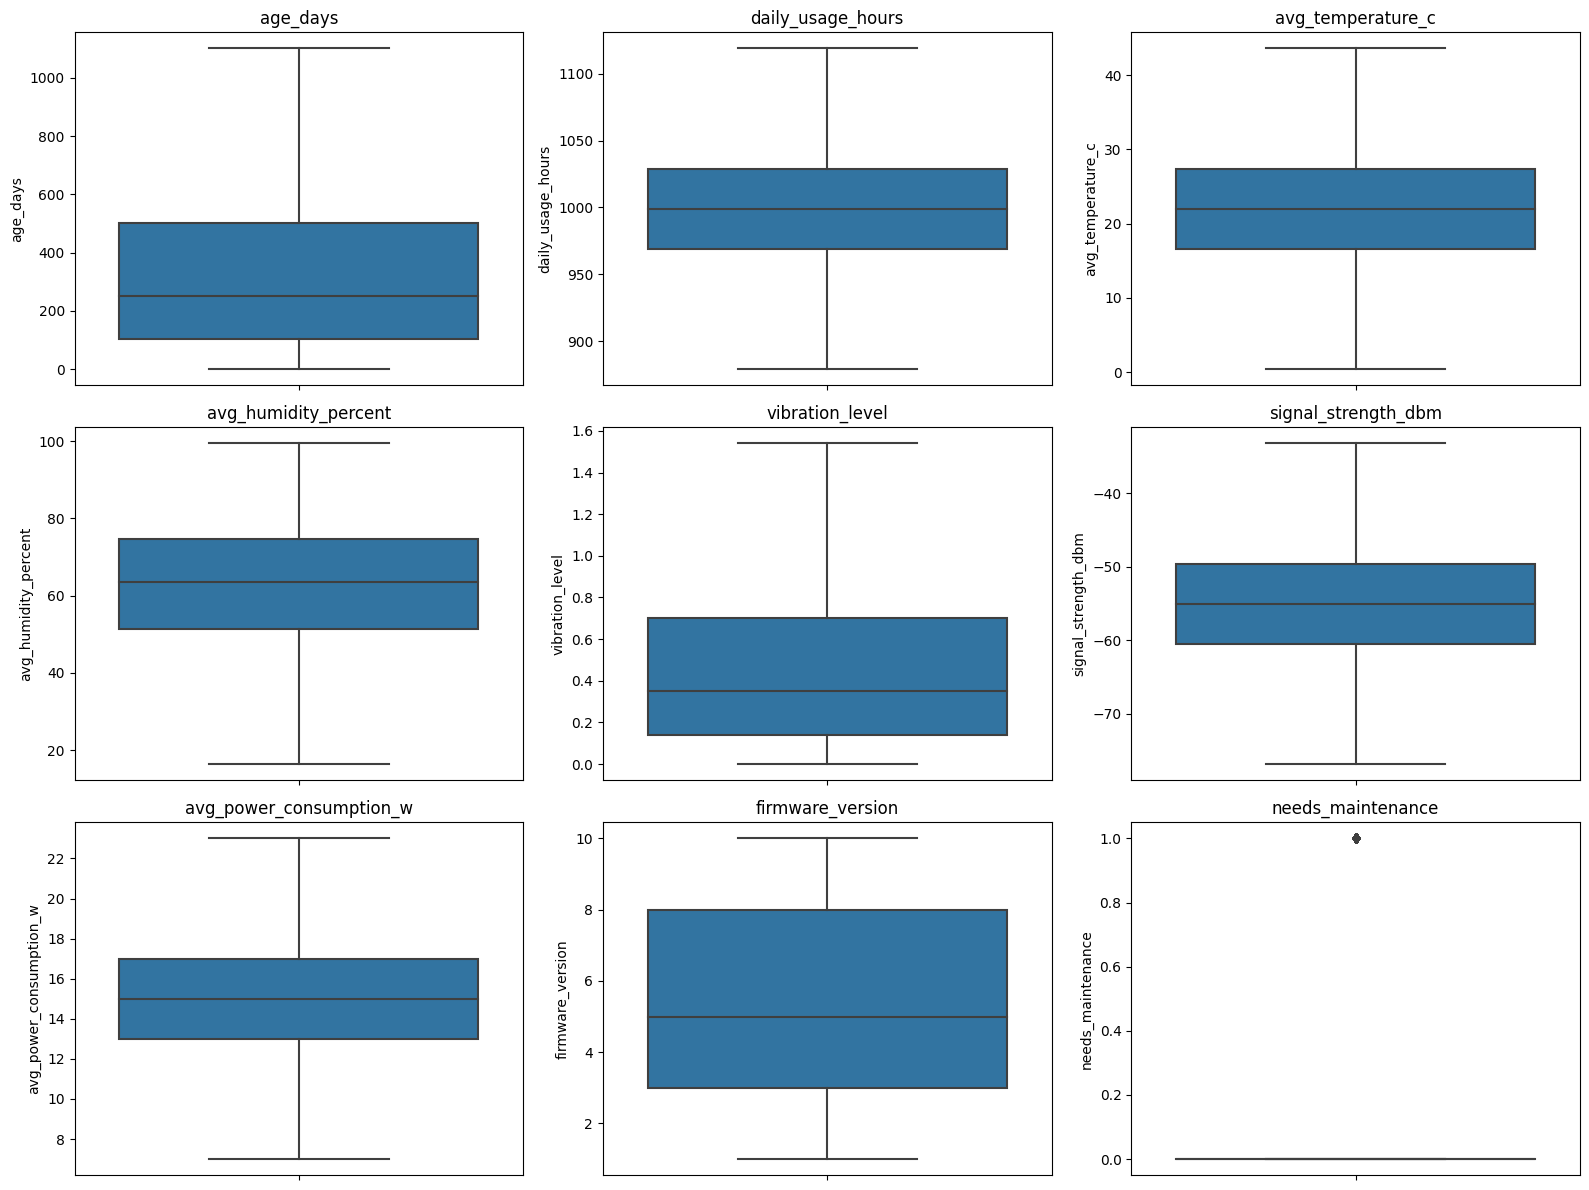

In [20]:
plt.figure(figsize=(16,12))

for i,col in enumerate(numcols):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

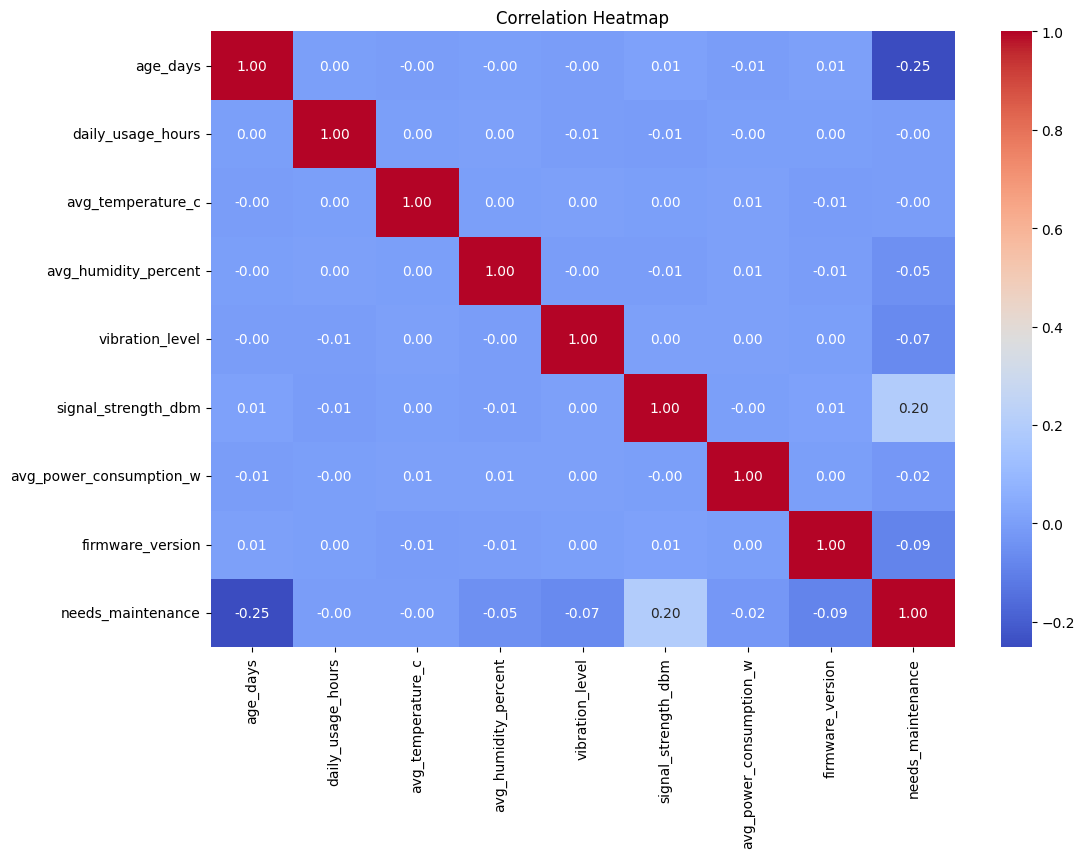

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numcols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
df['camera_age_years'] = df['age_days'] / 365

In [24]:
df["old_camera"] = (df["age_days"] > 1000).astype(int)

In [25]:
df["high_temp"] = (df["avg_temperature_c"] > 35).astype(int)

In [26]:
df["high_humidity"] = (df["avg_humidity_percent"] > 80).astype(int)

In [27]:
df["weak_signal"] = (df["signal_strength_dbm"] < -65).astype(int)

In [28]:
df["daily_usage_hours"] = df["daily_usage_hours"] / 60
df["high_usage"] = (df["daily_usage_hours"] > 18).astype(int)

In [29]:
df["power_per_hour"] = (df["avg_power_consumption_w"] / df["daily_usage_hours"])

In [30]:
df["temp_humidity"] = (df["avg_temperature_c"] * df["avg_humidity_percent"])

In [31]:
df["age_vibration"] = (df["camera_age_years"] * df["vibration_level"])

In [32]:
df["signal_quality"] = (100 + df["signal_strength_dbm"])

In [33]:
df["risk_score"] = (df["old_camera"] + df["high_temp"] +  df["high_humidity"] + df["weak_signal"] + df["high_usage"])

In [34]:
df.head()

,camera_id,age_days,daily_usage_hours,avg_temperature_c,avg_humidity_percent,vibration_level,signal_strength_dbm,avg_power_consumption_w,firmware_version,camera_type,...,old_camera,high_temp,high_humidity,weak_signal,high_usage,power_per_hour,temp_humidity,age_vibration,signal_quality,risk_score
0,CAM_033553,119.0,16.500000,33.2,68.8,0.39,-55.3,12.0,7,PTZ,...,0,0,0,0,0,0.727273,2284.16,0.127151,44.7,0
1,CAM_009427,678.0,17.083333,16.9,73.6,0.55,-57.8,14.0,8,Bullet,...,0,0,0,0,0,0.819512,1243.84,1.021644,42.2,0
2,CAM_000199,552.0,17.600000,22.6,72.2,0.05,-52.0,13.6,3,Thermal,...,0,0,0,0,0,0.772727,1631.72,0.075616,48.0,0
3,CAM_012447,1101.5,17.216667,25.9,77.5,0.45,-52.8,16.7,10,Bullet,...,1,0,0,0,0,0.969990,2007.25,1.358014,47.2,1
4,CAM_039489,339.0,17.350000,23.8,92.2,0.29,-52.8,14.9,7,Bullet,...,0,0,1,0,0,0.858790,2194.36,0.269342,47.2,1


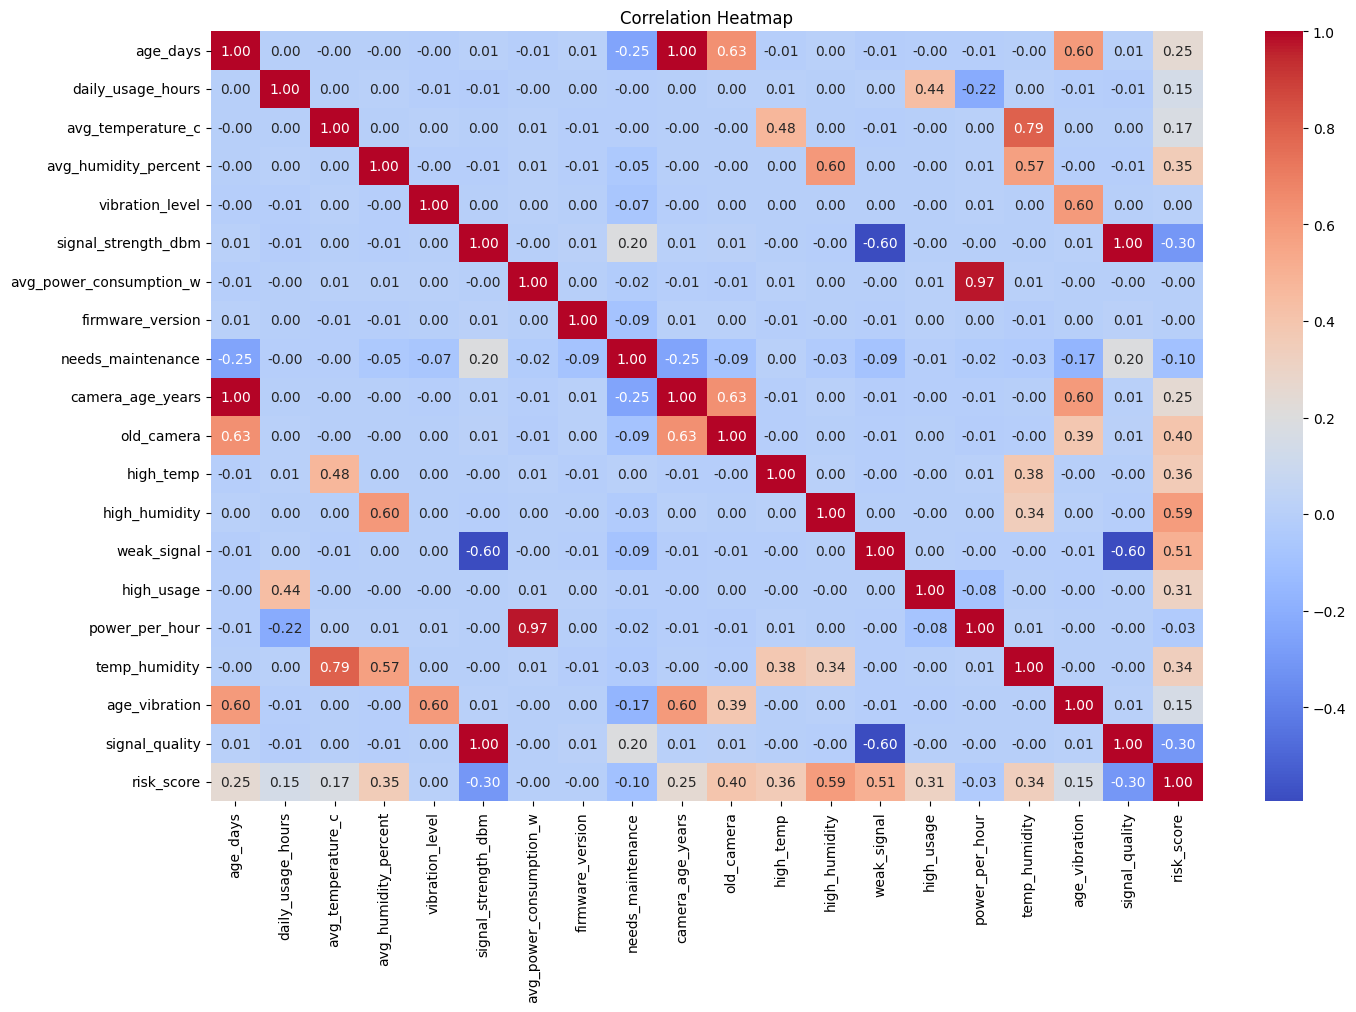

In [41]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    df.corr(),          # Removed numeric_only=True
    cmap="coolwarm",
    annot=True,         # Shows numbers in boxes (very useful)
    fmt=".2f"           # Shows 2 decimal places
)

plt.title("Correlation Heatmap")
plt.show()

In [42]:
df.to_csv(r"C:\Users\AiK\Machine Learning Projects\CCTV Maintanence\Model Building\data_processed.csv")